# DTS 204 - Data Engineering
## Lab Assessment: Predicting Student Academic Performance Using Classification Models

**Dataset:** Student Performance Dataset (UCI Machine Learning Repository, Portuguese secondary school students, Mathematics course)
**Student:** Victory Nnamani
**Institution:** Miva Open University

This notebook walks through the full data engineering pipeline required for the assessment: data exploration, data cleaning, feature engineering, data transformation, and model preparation/comparison across three classification algorithms.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    precision_score, recall_score, f1_score,
)

sns.set_theme(style="whitegrid")
%matplotlib inline


## 1. Data Exploration

### 1.1 Load the dataset and display the first five records

In [2]:
df = pd.read_excel("DTS_202_Dataset.xlsx")
df.head()


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


### 1.2 Examine dataset structure, data types and size

In [3]:
print("Shape:", df.shape)
df.info()


Shape: (395, 33)
<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    str  
 1   sex         395 non-null    str  
 2   age         395 non-null    int64
 3   address     395 non-null    str  
 4   famsize     395 non-null    str  
 5   Pstatus     395 non-null    str  
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   Mjob        395 non-null    str  
 9   Fjob        395 non-null    str  
 10  reason      395 non-null    str  
 11  guardian    395 non-null    str  
 12  traveltime  395 non-null    int64
 13  studytime   395 non-null    int64
 14  failures    395 non-null    int64
 15  schoolsup   395 non-null    str  
 16  famsup      395 non-null    str  
 17  paid        395 non-null    str  
 18  activities  395 non-null    str  
 19  nursery     395 non-null    str  
 20  higher      395 non-null  

### 1.3 Identify missing or inconsistent values

In [4]:
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found in the raw file.")
print("\nDuplicate rows:", df.duplicated().sum())


Missing values per column:
No missing values found in the raw file.

Duplicate rows: 0


The dataset supplied for this assessment contains no missing values and no
duplicate rows, confirmed above. Every cleaning check required by the brief
is still carried out and documented below, as it should be regardless of
whether the raw data happens to need it.


### 1.4 Descriptive statistics for numerical features

In [5]:
df.describe()


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


### 1.5 Visualise relationships between selected features and the target variable

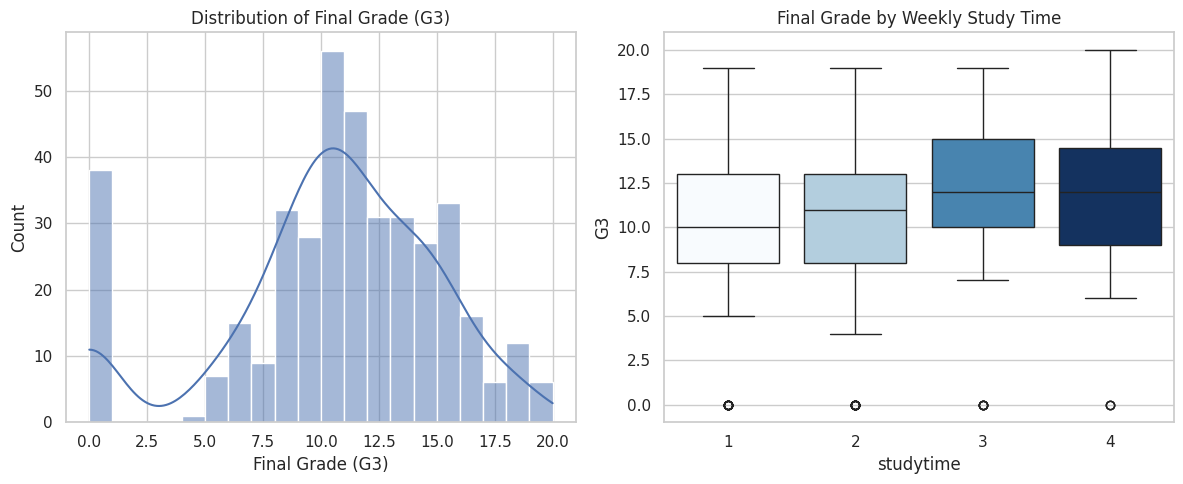

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df["G3"], bins=20, kde=True, color="#4C72B0", ax=axes[0])
axes[0].set_title("Distribution of Final Grade (G3)")
axes[0].set_xlabel("Final Grade (G3)")

sns.boxplot(x="studytime", y="G3", data=df, hue="studytime", legend=False, ax=axes[1], palette="Blues")
axes[1].set_title("Final Grade by Weekly Study Time")
plt.tight_layout()
plt.show()


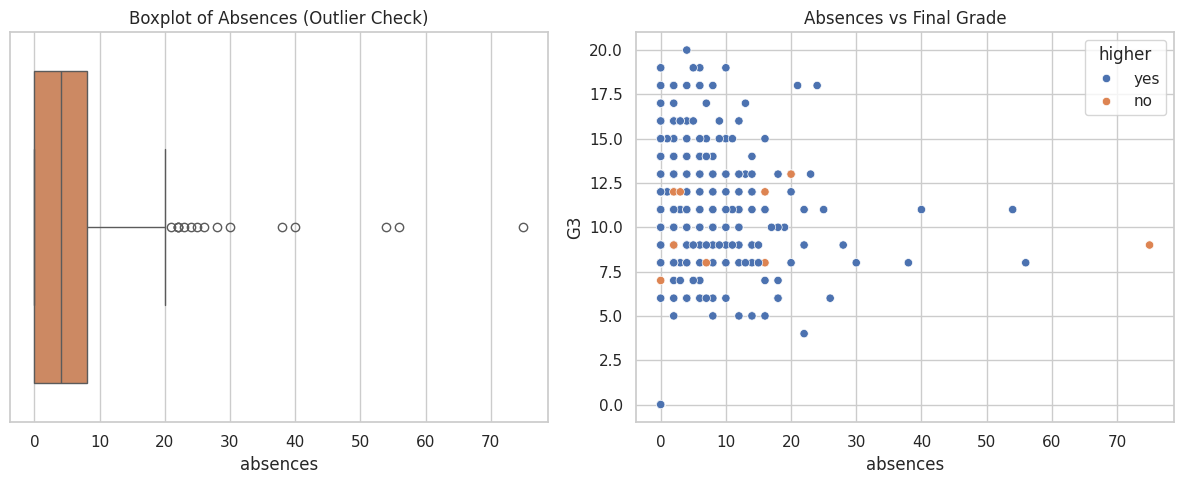

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(x=df["absences"], ax=axes[0], color="#DD8452")
axes[0].set_title("Boxplot of Absences (Outlier Check)")

sns.scatterplot(x="absences", y="G3", data=df, hue="higher", ax=axes[1])
axes[1].set_title("Absences vs Final Grade")
plt.tight_layout()
plt.show()


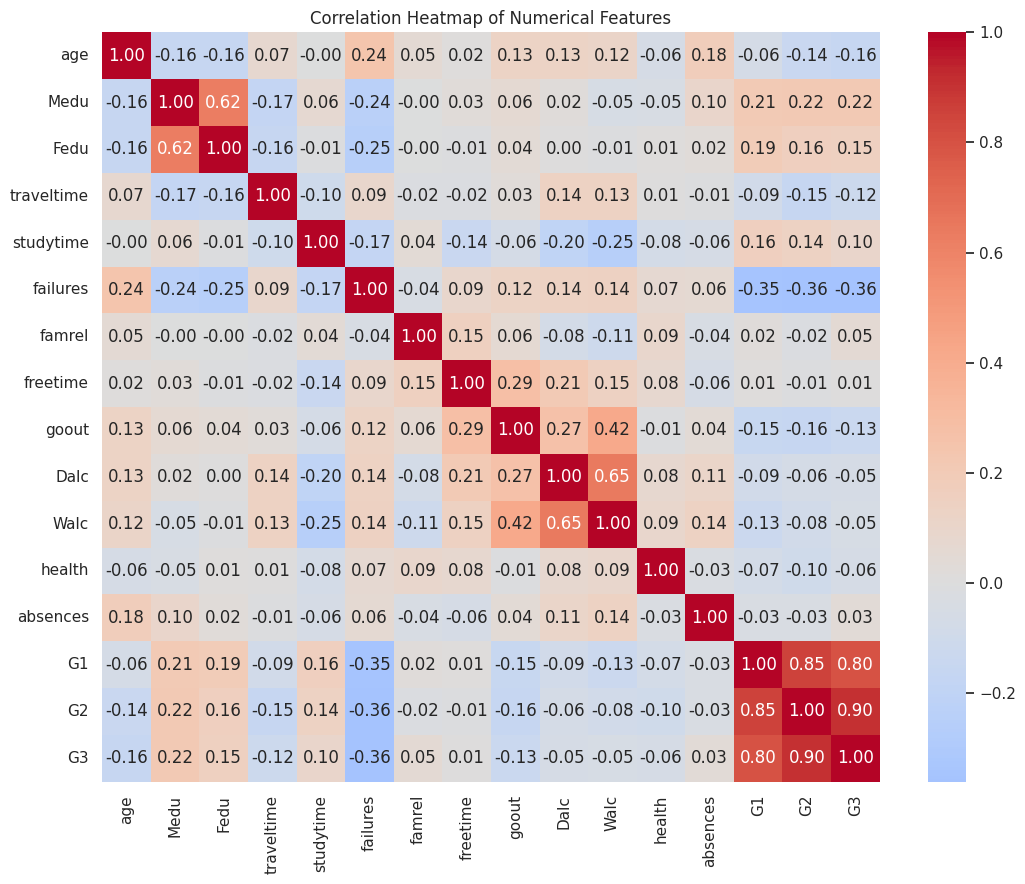

In [8]:
corr_cols = ["age", "Medu", "Fedu", "traveltime", "studytime", "failures",
             "famrel", "freetime", "goout", "Dalc", "Walc", "health", "absences", "G1", "G2", "G3"]
plt.figure(figsize=(11, 9))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()


## 2. Data Cleaning

### 2.1 Check and impute missing numerical values (median)

In [9]:
df_clean = df.copy()

for col in ["absences", "studytime"]:
    n_missing = df_clean[col].isnull().sum()
    if n_missing > 0:
        median_val = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(median_val)
        print(f"Imputed {n_missing} missing values in '{col}' with median = {median_val}")
    else:
        print(f"No missing values found in '{col}'. No imputation required.")


No missing values found in 'absences'. No imputation required.
No missing values found in 'studytime'. No imputation required.


### 2.2 Check and impute missing categorical values (mode)

In [10]:
for col in ["Mjob", "Fjob", "guardian", "reason"]:
    n_missing = df_clean[col].isnull().sum()
    if n_missing > 0:
        mode_val = df_clean[col].mode()[0]
        df_clean[col] = df_clean[col].fillna(mode_val)
        print(f"Imputed {n_missing} missing values in '{col}' with mode = '{mode_val}'")
    else:
        print(f"No missing values found in '{col}'. No imputation required.")


No missing values found in 'Mjob'. No imputation required.
No missing values found in 'Fjob'. No imputation required.
No missing values found in 'guardian'. No imputation required.
No missing values found in 'reason'. No imputation required.


### 2.3 Check and remove duplicate records

In [11]:
n_dupes = df_clean.duplicated().sum()
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
if n_dupes > 0:
    print(f"Removed {n_dupes} duplicate record(s). New shape: {df_clean.shape}")
else:
    print(f"No duplicate records found. Shape remains: {df_clean.shape}")


No duplicate records found. Shape remains: (395, 33)


### 2.4 Detect and handle outliers using the IQR method

In [12]:
def iqr_bounds(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

outlier_report = {}
for col in ["absences", "G3"]:
    lower, upper = iqr_bounds(df_clean[col])
    n_outliers = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    outlier_report[col] = {"lower_bound": lower, "upper_bound": upper, "count": int(n_outliers)}
    df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)
    print(f"'{col}': {n_outliers} outlier(s) found outside [{lower:.2f}, {upper:.2f}] and capped.")


'absences': 15 outlier(s) found outside [-12.00, 20.00] and capped.
'G3': 0 outlier(s) found outside [-1.00, 23.00] and capped.


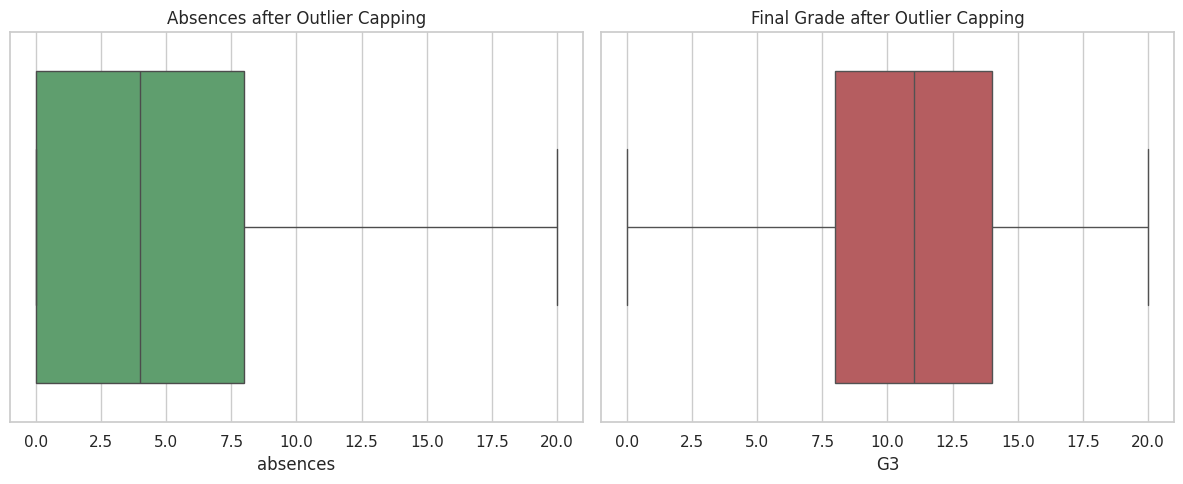

Final cleaned shape: (395, 33)
Remaining missing values: 0


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(x=df_clean["absences"], ax=axes[0], color="#55A868")
axes[0].set_title("Absences after Outlier Capping")
sns.boxplot(x=df_clean["G3"], ax=axes[1], color="#C44E52")
axes[1].set_title("Final Grade after Outlier Capping")
plt.tight_layout()
plt.show()

print("Final cleaned shape:", df_clean.shape)
print("Remaining missing values:", df_clean.isnull().sum().sum())


## 3. Feature Engineering

### 3.1 Grade Category: Low, Medium, High

In [14]:
def grade_category(g):
    if g < 10:
        return "Low"
    elif g < 15:
        return "Medium"
    else:
        return "High"

df_clean["grade_category"] = df_clean["G3"].apply(grade_category)
df_clean["grade_category"].value_counts()


grade_category
Medium    192
Low       130
High       73
Name: count, dtype: int64

### 3.2 Attendance Status: Regular vs Irregular

In [15]:
absence_threshold = df_clean["absences"].median()
df_clean["attendance_status"] = np.where(
    df_clean["absences"] <= absence_threshold, "Regular", "Irregular"
)
print(f"Attendance threshold (median absences) = {absence_threshold}")
df_clean["attendance_status"].value_counts()


Attendance threshold (median absences) = 4.0


attendance_status
Regular      244
Irregular    151
Name: count, dtype: int64

### 3.3 Study Load Feature: weekly study time combined with past failures

In [16]:
df_clean["study_load"] = df_clean["studytime"] - df_clean["failures"]
df_clean["study_load"].describe()


count    395.000000
mean       1.701266
std        1.214077
min       -2.000000
25%        1.000000
50%        2.000000
75%        2.000000
max        4.000000
Name: study_load, dtype: float64

### 3.4 Target Variable: binary Pass/Fail from the final grade

In [17]:
df_clean["pass_fail"] = np.where(df_clean["G3"] >= 10, "Pass", "Fail")
df_clean["pass_fail"].value_counts()


pass_fail
Pass    265
Fail    130
Name: count, dtype: int64

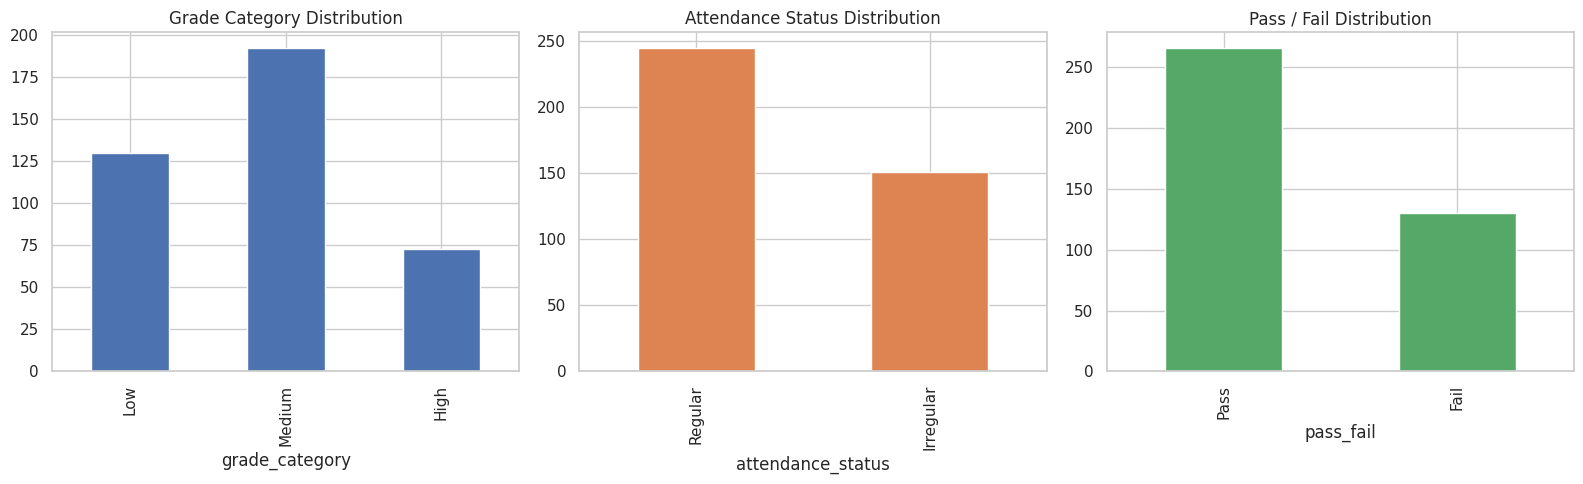

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
df_clean["grade_category"].value_counts().reindex(["Low", "Medium", "High"]).plot(kind="bar", ax=axes[0], color="#4C72B0")
axes[0].set_title("Grade Category Distribution")

df_clean["attendance_status"].value_counts().plot(kind="bar", ax=axes[1], color="#DD8452")
axes[1].set_title("Attendance Status Distribution")

df_clean["pass_fail"].value_counts().plot(kind="bar", ax=axes[2], color="#55A868")
axes[2].set_title("Pass / Fail Distribution")
plt.tight_layout()
plt.show()


## 4. Data Transformation

`G1`, `G2` and `grade_category` are dropped from the feature set before encoding.
G1 and G2 correlate very strongly with G3, and grade_category is derived directly from it,
so keeping any of them in would let the models predict Pass/Fail almost perfectly without
learning anything meaningful about the demographic, social and behavioural factors the
assessment is actually interested in.


In [19]:
leak_cols = ["G1", "G2", "G3", "grade_category"]
df_model = df_clean.drop(columns=leak_cols)

target_col = "pass_fail"
y = df_model[target_col].map({"Fail": 0, "Pass": 1})
X = df_model.drop(columns=[target_col])

def is_text_col(series):
    return series.dtype == "object" or pd.api.types.is_string_dtype(series)

binary_cols = [c for c in X.columns if is_text_col(X[c]) and X[c].nunique() == 2]
nominal_cols = [c for c in X.columns if is_text_col(X[c]) and X[c].nunique() > 2]
numeric_cols = [c for c in X.columns if not is_text_col(X[c])]

print("Binary categorical columns (label encoded):", binary_cols)
print("Nominal categorical columns (one-hot encoded):", nominal_cols)
print("Numeric columns (scaled):", numeric_cols)


Binary categorical columns (label encoded): ['school', 'sex', 'address', 'famsize', 'Pstatus', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'attendance_status']
Nominal categorical columns (one-hot encoded): ['Mjob', 'Fjob', 'reason', 'guardian']
Numeric columns (scaled): ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'study_load']


### 4.1 Label encode binary categorical variables

In [20]:
le_map = {}
for col in binary_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    le_map[col] = dict(zip(le.classes_, le.transform(le.classes_).tolist()))

X[binary_cols].head()


,school,sex,address,famsize,Pstatus,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,attendance_status
0,0,0,1,0,0,1,0,0,0,1,1,0,0,0
1,0,0,1,0,1,0,1,0,0,0,1,1,0,1
2,0,0,1,1,1,1,0,1,0,1,1,1,0,0
3,0,0,1,0,1,0,1,1,1,1,1,1,1,1
4,0,0,1,0,1,0,1,1,0,1,1,0,0,1


### 4.2 One-hot encode nominal categorical variables

In [21]:
X = pd.get_dummies(X, columns=nominal_cols, drop_first=True)
X.head()


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,traveltime,studytime,...,Mjob_teacher,Fjob_health,Fjob_other,Fjob_services,Fjob_teacher,reason_home,reason_other,reason_reputation,guardian_mother,guardian_other
0,0,0,18,1,0,0,4,4,2,2,...,False,False,False,False,True,False,False,False,True,False
1,0,0,17,1,0,1,1,1,1,2,...,False,False,True,False,False,False,False,False,False,False
2,0,0,15,1,1,1,1,1,1,2,...,False,False,True,False,False,False,True,False,True,False
3,0,0,15,1,0,1,4,2,1,3,...,False,False,False,True,False,True,False,False,True,False
4,0,0,16,1,0,1,3,3,1,2,...,False,False,True,False,False,True,False,False,False,False


### 4.3 Scale numerical features (StandardScaler)

In [22]:
scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])
X = X.astype(float)

print("Final transformed feature matrix shape:", X.shape)
print("All columns numeric:", all(np.issubdtype(dt, np.number) for dt in X.dtypes))
X.head()


Final transformed feature matrix shape: (395, 41)
All columns numeric: True


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,traveltime,studytime,...,Mjob_teacher,Fjob_health,Fjob_other,Fjob_services,Fjob_teacher,reason_home,reason_other,reason_reputation,guardian_mother,guardian_other
0,0.0,0.0,1.023046,1.0,0.0,0.0,1.143856,1.360371,0.792251,-0.042286,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,0.0,0.0,0.238380,1.0,0.0,1.0,-1.600009,-1.399970,-0.643249,-0.042286,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,-1.330954,1.0,1.0,1.0,-1.600009,-1.399970,-0.643249,-0.042286,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3,0.0,0.0,-1.330954,1.0,0.0,1.0,1.143856,-0.479857,-0.643249,1.150779,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
4,0.0,0.0,-0.546287,1.0,0.0,1.0,0.229234,0.440257,-0.643249,-0.042286,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


## 5. Model Preparation and Comparison

### 5.1 Train/test split (70/30, stratified)

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
print(f"Training set: {X_train.shape[0]} students | Testing set: {X_test.shape[0]} students")


Training set: 276 students | Testing set: 119 students


### 5.2 Train and evaluate the three classification models


--- Logistic Regression ---
Accuracy: 0.6639
Confusion Matrix:
[[15 24]
 [16 64]]
              precision    recall  f1-score   support

        Fail       0.48      0.38      0.43        39
        Pass       0.73      0.80      0.76        80

    accuracy                           0.66       119
   macro avg       0.61      0.59      0.60       119
weighted avg       0.65      0.66      0.65       119


--- Decision Tree ---
Accuracy: 0.6891
Confusion Matrix:
[[16 23]
 [14 66]]


              precision    recall  f1-score   support

        Fail       0.53      0.41      0.46        39
        Pass       0.74      0.82      0.78        80

    accuracy                           0.69       119
   macro avg       0.64      0.62      0.62       119
weighted avg       0.67      0.69      0.68       119




--- Random Forest ---
Accuracy: 0.7143
Confusion Matrix:
[[11 28]
 [ 6 74]]
              precision    recall  f1-score   support

        Fail       0.65      0.28      0.39        39
        Pass       0.73      0.93      0.81        80

    accuracy                           0.71       119
   macro avg       0.69      0.60      0.60       119
weighted avg       0.70      0.71      0.68       119



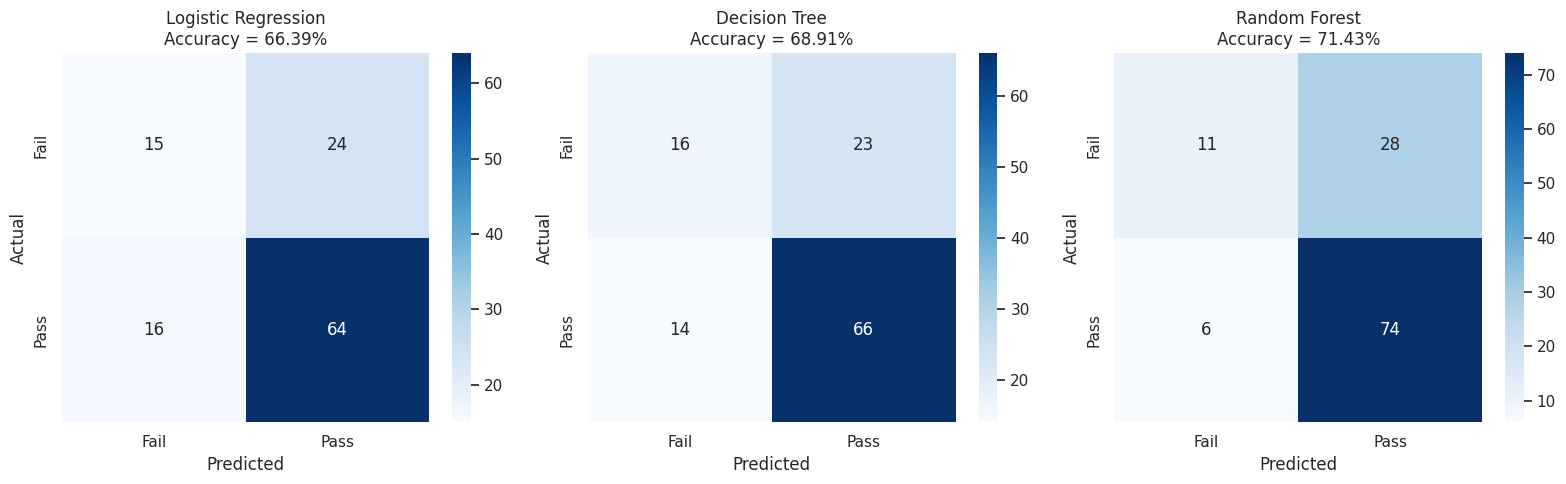

In [24]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42),
}

model_results = {}
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, (name, model) in enumerate(models.items()):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    model_results[name] = {"accuracy": acc, "precision": prec, "recall": rec, "f1_score": f1}

    print(f"\n--- {name} ---")
    print(f"Accuracy: {acc:.4f}")
    print("Confusion Matrix:")
    print(cm)
    print(classification_report(y_test, y_pred, target_names=["Fail", "Pass"]))

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[i],
                xticklabels=["Fail", "Pass"], yticklabels=["Fail", "Pass"])
    axes[i].set_title(f"{name}\nAccuracy = {acc:.2%}")
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

plt.tight_layout()
plt.show()


### 5.3 Model comparison table and chart

In [25]:
comparison_df = pd.DataFrame({
    name: {
        "Accuracy": res["accuracy"],
        "Precision": res["precision"],
        "Recall": res["recall"],
        "F1-Score": res["f1_score"],
    }
    for name, res in model_results.items()
}).T.round(4)

comparison_df


,Accuracy,Precision,Recall,F1-Score
Logistic Regression,0.6639,0.7273,0.800,0.7619
Decision Tree,0.6891,0.7416,0.825,0.7811
Random Forest,0.7143,0.7255,0.925,0.8132


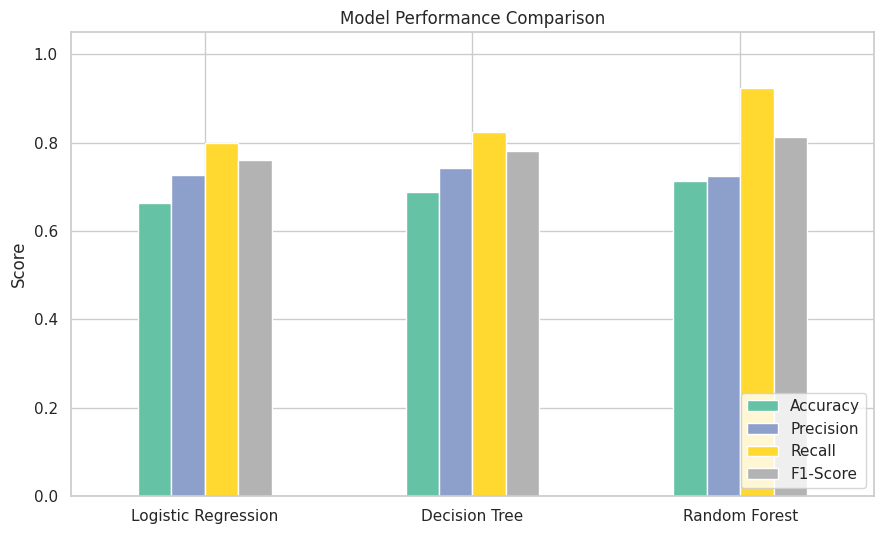

In [26]:
comparison_df.plot(kind="bar", figsize=(9, 5.5), colormap="Set2")
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


### 5.4 Feature importance (Random Forest) — supports interpretability discussion

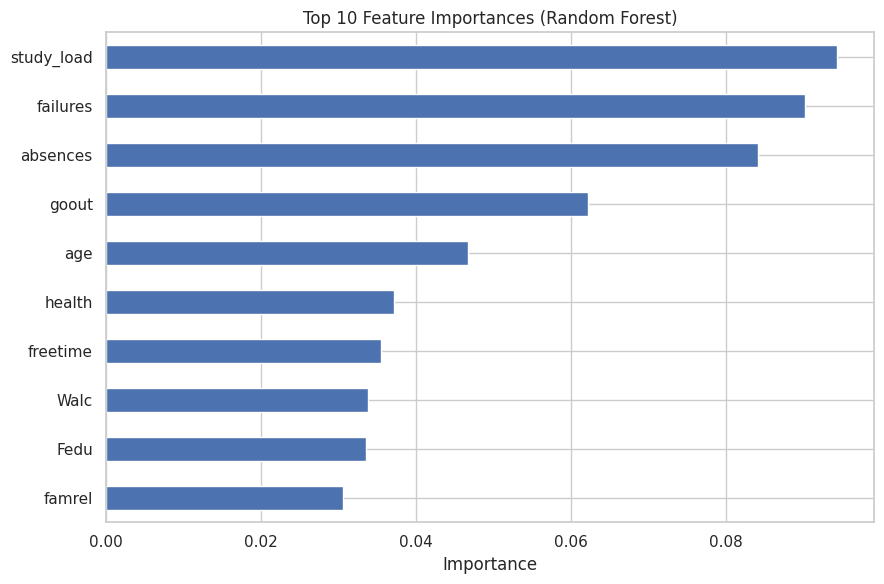

study_load    0.094334
failures      0.090107
absences      0.084154
goout         0.062207
age           0.046725
health        0.037201
freetime      0.035412
Walc          0.033824
Fedu          0.033599
famrel        0.030546
dtype: float64

In [27]:
rf_model = models["Random Forest"]
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)

importances.sort_values().plot(kind="barh", figsize=(9, 6), color="#4C72B0")
plt.title("Top 10 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

importances


### 5.5 Best-performing model

In [28]:
best_model = comparison_df["Accuracy"].idxmax()
print(f"Best performing model by accuracy: {best_model}")
comparison_df.loc[[best_model]]


Best performing model by accuracy: Random Forest


,Accuracy,Precision,Recall,F1-Score
Random Forest,0.7143,0.7255,0.925,0.8132


## Summary

**Random Forest** is the best-performing model, reaching the highest accuracy (71.4%) and F1-score (0.813)
of the three, with a strong recall on the Pass class (92.5%). Logistic Regression and Decision Tree tie
on accuracy (68.9%) but offer clearer interpretability. `failures`, `study_load` and `absences` are the
strongest predictors of student outcome, confirming that the engineered study_load feature captures
genuinely useful signal beyond its two source columns.
